Moving away from `blochstate`.

In [1]:
# import all the E9 stuff
import logging
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import time
from scipy.linalg import eigh
from scipy.interpolate import interp1d
from scipy.integrate import quad

# User defined modules
E9path = Path("C:/", "Users", "ken92", "Documents", "Studies", "E5", "simulation", "E9_simulations")
if str(E9path) not in sys.path:
    sys.path.insert(1, str(E9path))
import E9_fn.E9_constants as E9c
import E9_fn.E9_atom as E9a
import E9_fn.E9_cooltrap as E9ct
import E9_fn.plane_wave_expansion.blochstate_class as bsc
import E9_fn.polarizabilities_calculation as E9pol
# import E9_fn.datasets.transition_line_data as TLData
from E9_fn import util

# Logging
logpath = '' # '' if not logging to a file
loglevel = logging.INFO
logroot = logging.getLogger()
list(map(logroot.removeHandler, logroot.handlers))
list(map(logroot.removeFilter, logroot.filters))
logging.basicConfig(filename = logpath, level = loglevel)

c:\Users\ken92\Documents\Studies\E5\simulation\E9_simulations\.venv\Lib\site-packages\gftool\precision.py:16: UserWarning: No quad precision datatypes available!
Some functions might be less accurate.
  warnings.warn("No quad precision datatypes available!\n"


# Inputs

In [2]:
species = "K40" # "Rb87", "K40"

# lattice parameters
# V1064Er = 5.            # 1064 lattice depth, in recoil energy
# V532Er = 3.             # 532 lattice depth, in recoil energy
# Rb kHz to Er
# V1064Er = 39.5 / 2.02781   # 25.213063
# V532Er = 0. / 8.11125    # 35.517929
# K kHz to Er
V1064Er = 39.5 / 4.4099   # 39.5
V532Er = 0 / 17.6394    # 35.517929
n0nom = 0               # peak density
# The superlattice phase that determines the relative position between 1064 and 532 lattice
# 532 lattice is fixed at 0, so changing the pase by pi for 1064 restores the original lattice
phi12, phi23 = 0., 0.
# phi12, phi23 = 0, np.pi/5
# phi12, phi23 = np.pi*2/3, -np.pi*2/3    # decorated triangular lattice
ABoffset1064nom = 0     # max 0.011585 * V1064nom / 9 / np.sqrt(3) for Rb
B1_rel_int_1064 = 1     # relative intensity (field is sqrt of that) of 1064 B1
B1_rel_int_532  = 1     # relative intensity (field is sqrt of that) of 532 B1
B3_rel_int_1064 = 1     # relative intensity (field is sqrt of that) of 1064 B3
B3_rel_int_532  = 1     # relative intensity (field is sqrt of that) of 532 B3

# Basic simulation parameters
num = 5             # size of q-momentum space we consider: (-num, num) (usually 5)
k_center = (0, 0)
bandstart = 0       # starting from 0, inclusive
bandend = 5         # inclusive
# qverts_str = 'E9c.Kp/E9c.k_lw, E9c.Kp2/E9c.k_lw, E9c.Kp3/E9c.k_lw, E9c.Kp4/E9c.k_lw, E9c.Kp5/E9c.k_lw, E9c.Kp6/E9c.k_lw, E9c.Kp/E9c.k_lw'
qverts_str = 'np.array([-np.sqrt(3)/2, 3/4]), np.array([-np.sqrt(3)/2, -3/4]), np.array([np.sqrt(3)/2, -3/4]), np.array([np.sqrt(3)/2, 3/4]), np.array([-np.sqrt(3)/2, 3/4])'

# Initialization
## Units

In [3]:
if species == "Rb87":
    all_units_dict = E9c.all_lat_unit_Rb87
    Er_1064 = E9c.E_r1064_Rb87
    Er_532 = E9c.E_r532_Rb87
elif species == "K40":
    all_units_dict = E9c.all_lat_unit_K40
    Er_1064 = E9c.E_r1064_K40
    Er_532 = E9c.E_r532_K40
else:
    raise ValueError("Unknown species: {}".format(species))
m_unit = all_units_dict["m_unit"]
l_unit = all_units_dict["l_unit"]
E_unit = all_units_dict["E_unit"]
f_unit = all_units_dict["f_unit"]
t_unit = all_units_dict["t_unit"]

V532nom = V532Er * Er_532 / E9c.hnobar / 1e3       # in kHz (i.e. V_SI / hbar / 1e3 / 2pi), assuming that polarizability is accounted for correctly
V1064nom = V1064Er * Er_1064  / E9c.hnobar / 1e3   # Note that setting this to 0 doesn't give you a proper band structure of 532 nm lattice, since you are now
                                # considering too many plane waves that don't actually contribute.
V532 = 2 * np.pi * V532nom * 1e3 / f_unit   # 2 * np.pi because I have f = E/hbar instead of E/h as normally defined
V1064 = 2 * np.pi * V1064nom * 1e3 / f_unit
ABoffset1064 = 2 * np.pi * ABoffset1064nom * 1e3 / f_unit
n0 = n0nom * l_unit**3

In [4]:
Exp_lib = {"species": species, "units_dict": all_units_dict
        , 'V532': V532, 'V1064': V1064, 'V532nom': V532nom, 'V1064nom': V1064nom, 'V532Er': V532Er, 'V1064Er': V1064Er
        , 'B1_rel_int_532': B1_rel_int_532, 'B1_rel_int_1064': B1_rel_int_1064, 'B3_rel_int_532': B3_rel_int_532, 'B3_rel_int_1064': B3_rel_int_1064
        , 'n0nom': n0nom, 'n0': n0
        , 'ABoffset1064nom': ABoffset1064nom, 'ABoffset1064': ABoffset1064
        , 'phi12': phi12, 'phi23': phi23}

str_lat_param_name = f"V532Er{V532Er:.3f}_V1064Er{V1064Er:.3f}"
for s in ['B1_rel_int_532', 'B1_rel_int_1064', 'B3_rel_int_532', 'B3_rel_int_1064']:
    val = Exp_lib[s]
    if not np.isclose(Exp_lib[s], 1): str_lat_param_name += f"_{s}{val:.3f}"
for s in ['ABoffset1064nom', 'ABoffset1064', 'phi12', 'phi23']:
    val = Exp_lib[s]
    if not np.isclose(Exp_lib[s], 0): str_lat_param_name += f"_{s}{val:.3f}"
print(f"lattice string:\n{str_lat_param_name}")
str_calc_param_name = f"_Nk{num}_band{bandstart}to{bandend}"

DoS_folder_path = Path(r"C:\Users\ken92\Documents\Studies\E5\simulation\E9_simulations\projects\general_cooling_trapping\lattice_DoS")
DoS_save_path = Path(DoS_folder_path, str_lat_param_name + str_calc_param_name)

DoS_load_path = None
matching_files_list = [p for p in DoS_folder_path.glob(f"{str_lat_param_name}*")]
if len(matching_files_list) > 0:
    DoS_load_path = matching_files_list[0]
    logging.info(f"Found {len(matching_files_list)} matching file(s)! Will use the first one:")
    logging.info(f"{DoS_load_path}")

size = 2 * num + 1
bandnum = bandend - bandstart + 1 # number of bands interested in
qverts_arr = eval(qverts_str)

INFO:root:Found 1 matching file(s)! Will use the first one:
INFO:root:C:\Users\ken92\Documents\Studies\E5\simulation\E9_simulations\projects\general_cooling_trapping\lattice_DoS\V532Er0.000_V1064Er8.957_Nk5_band0to5.npz


lattice string:
V532Er0.000_V1064Er8.957


# Real space plots

In [5]:
a_tri_um = E9c.a_sw_tri * 1e6
uc_vertices = [a_tri_um * np.array([-np.sqrt(3) * 4 / 3, 0]),
               a_tri_um * np.array([-np.sqrt(3) / 2, 1]),
               a_tri_um * np.array([np.sqrt(3) / 3, 0]),
               a_tri_um * np.array([-np.sqrt(3) / 2, -1]),]
uc_vertices.append(uc_vertices[0])

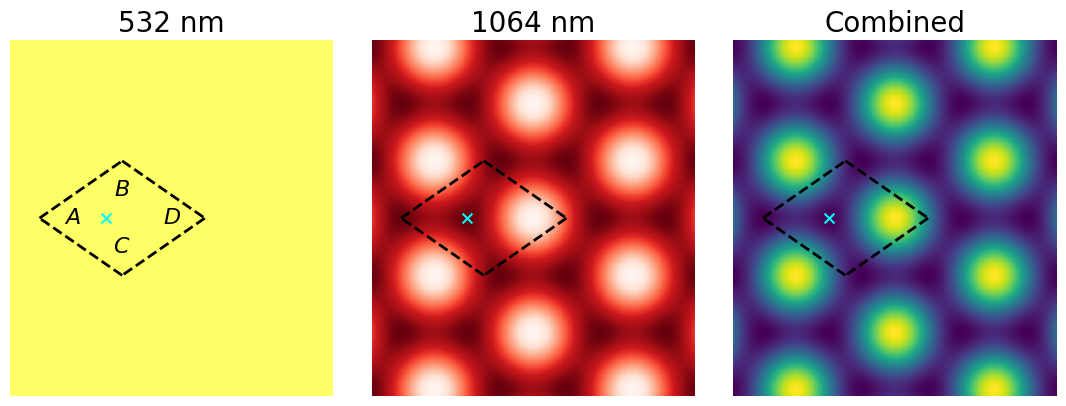

In [6]:
x_real = np.linspace(-1, 1, 500) * 1e-6
y_real = np.linspace(-1.1, 1.1, 500) * 1e-6
x_real_um = np.linspace(-1, 1, 500)
y_real_um = np.linspace(-1.1, 1.1, 500)

pos_delta = E9c.l_cell_lw * E9c.k1k * (phi12 / 2 / np.pi) + E9c.l_cell_lw * E9c.k3k * (phi23 / 2 / np.pi)
x_delta, y_delta = pos_delta # should be simple functions of phi12 and phi23
V_532_real = bsc.get_Vin(x_real, y_real, V532, B1_rel_int_532, B3_rel_int_532, 0, 0, 1)
V_1064_real = - bsc.get_Vin(x_real, y_real, V1064, B1_rel_int_1064, B3_rel_int_1064, x_delta, y_delta, 2)
V_super_real = V_532_real + V_1064_real

fig_real, (ax_532, ax_1064, ax_super) = plt.subplots(1, 3, figsize = (11, 4))
# fig_real.suptitle("Real space potential")
ax_532.set_ylabel("y (um)")
ax_1064.set_xlabel("x (um)")

for ax, V_real, ax_title, cmap_str in zip([ax_532, ax_1064, ax_super],
                                        [V_532_real, V_1064_real, V_super_real],
                                        ["532 nm", "1064 nm", "Combined"],
                                        ["summer_r", 'Reds_r', "viridis"],):
    ax.set_aspect("equal")
    im = ax.pcolormesh(x_real_um, y_real_um, V_real, cmap = cmap_str)
    # ax.scatter(0, 0, color = 'red', marker = '+', s = 50)   # origin
    ax.scatter(-a_tri_um * 2 / np.sqrt(3), 0, color = 'cyan', marker = 'x', s = 50)   # 1064 site
    
    # add unit cell
    for p1, p2 in zip(uc_vertices[:-1], uc_vertices[1:]):
        x1, y1 = p1
        x2, y2 = p2
        ax.plot([x1, x2], [y1, y2], color = "black", ls = "--", lw = 2)

    ax.set_title(ax_title, fontsize = 20)
    ax.axis("off")
    # fig_real.colorbar(im, ax = ax)

# add sublattice labels
ax_532.text(-a_tri_um * np.sqrt(3), 0, r"$A$", size = 16,
            horizontalalignment = "center", verticalalignment = "center")
ax_532.text(-a_tri_um * np.sqrt(3) / 2, a_tri_um / 2, r"$B$", size = 16,
            horizontalalignment = "center", verticalalignment = "center")
ax_532.text(-a_tri_um * np.sqrt(3) / 2, - a_tri_um / 2, r"$C$", size = 16,
            horizontalalignment = "center", verticalalignment = "center")
ax_532.text(0, 0, r"$D$", size = 16,
            horizontalalignment = "center", verticalalignment = "center")

fig_real.tight_layout()

# Finding Bloch states and band energies

In [7]:
if DoS_load_path is None:
    start_time = time.time()

    # Generate qset
    dq = 0.015
    qsets = bsc.FindqArea(qverts_arr, dqx = dq, dqy = dq)
    N_qsample = len(qsets)
    print("Total number of points = {0}".format(N_qsample))
    # PlotBZinput = (qverts_str, qsets)
    # ax_BZ = bsc.PlotBZSubplot()
    # bsc.plot_qset(ax_BZ, qset = PlotBZinput, qset_type = "explicit")

    # find non-interacting solution
    e_values = np.zeros((len(qsets), bandnum), dtype = np.cdouble)
    e_states = np.zeros((len(qsets), size**2, bandnum), dtype = np.cdouble)
    e_states_ni = [[] for _ in range(bandnum)]  # a list of blochstate for each band

    Hq_mmat, Hq_nmat, H_532, H_1064 = bsc.find_H_components(num, Exp_lib, center = k_center)
    for i in range(len(qsets)):
        H = bsc.find_H(qsets[i], Exp_lib, Hq_mmat, Hq_nmat, H_532, H_1064)
        assert util.IsHermitian(H)
        e_values[i,:], e_states[i,:,:] = eigh(H, eigvals = (bandstart, bandend),
                                            overwrite_a = True, check_finite = False)

    # Fix the gauge of eigenstates using parallel transport
    e_states_fixed = bsc.fix_gauge_2d_grid(e_states, qsets, neighbor_dist = dq * 1.4)   # Using 1.5 is not good since 1.5 > sqrt(2)
    for i in range(len(qsets)):
        for j, bandN in enumerate(range(bandstart, bandend + 1)):
            e_states_ni[j].append(bsc.blochstate(e_states[i,:,j], q = qsets[i], center = k_center, N = bandN, E = e_values[i,j], param = Exp_lib))
    print("--- {0} seconds ---".format((time.time() - start_time)))

I always get a `ComplexWarning` when running `.astype(np.double)`, but if my own check doesn't raise a warning all is good.

In [8]:
if DoS_load_path is None:
    if not np.all(np.isreal(e_values)):
        logging.warning('Complex eigenvalue detected. Imaginary parts are discarded.')
    e_values = e_values.astype(np.double)

## Band structure plot
I'm not sure about the energy at zero yet

In [9]:
E2kHz = E_unit / E9c.hnobar / 1e3 # conversion factor from natural units to kHz

In [10]:
if DoS_load_path is None:
    E_lowest = np.min(e_values)
    E_kHz_offset = (e_values - E_lowest) * E2kHz
    E_kHz_highest = np.max(E_kHz_offset)

    all_energies = E_kHz_offset.flatten()
    DoS_from_bin, bin_edges = np.histogram(all_energies, bins = 1000)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    n_of_mu = np.cumsum(DoS_from_bin) / N_qsample
    np.savez(DoS_save_path, bin_edges = bin_edges, DoS_from_bin = DoS_from_bin, n_of_mu = n_of_mu)
else:
    loaded_npz = np.load(DoS_load_path)
    bin_edges = loaded_npz["bin_edges"]
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    DoS_from_bin = loaded_npz["DoS_from_bin"]
    n_of_mu = loaded_npz["n_of_mu"]

# Integral of density of states

In [11]:
mu_kHz_range = np.linspace(0, 15, 100)
# mu_kHz_range = np.linspace(0, E_kHz_highest, 100)

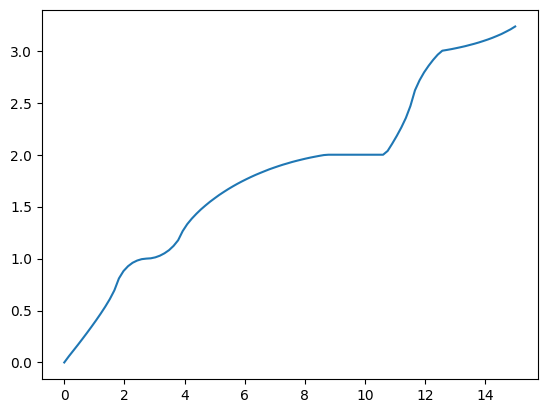

In [12]:
n_per_uc_hc_mu_kHz = interp1d(
    bin_centers, 
    n_of_mu, 
    kind='linear', 
    bounds_error=False, 
    fill_value=(0, n_of_mu[-1])
)
density_local = n_per_uc_hc_mu_kHz(mu_kHz_range)
plt.plot(mu_kHz_range, density_local)

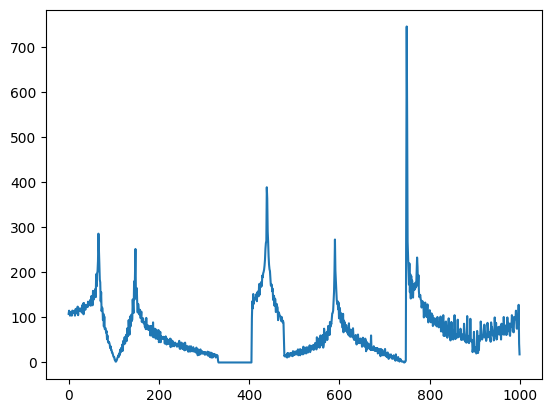

In [13]:
plt.plot(DoS_from_bin)


In [14]:
def rho1D_P_in_a_box(mu_kHz):
    if mu_kHz <= 0: return 0
    return np.sqrt(2 * E9c.m_K40 / (mu_kHz * 1e3 * E9c.hnobar)) / E9c.hnobar / 1e6 * E9c.hnobar * 1e3

def n1D_P_in_a_box(mu_kHz):
    """Number of particles per um at chemical potential mu in a infinite particle in a box"""
    if mu_kHz <= 0: return 0
    return np.sqrt(8 * E9c.m_K40 * mu_kHz * 1e3 * E9c.hnobar) / E9c.hnobar / 1e6

def n3D_per_um3_hc_mu_kHz(mu_kHz):
    nz = lambda x: rho1D_P_in_a_box(mu_kHz - x)
    n3D = lambda x: nz(x) * n_per_uc_hc_mu_kHz(x) * E9c.n_site_hex / 2 / 1e12
    return quad(n3D, 0, mu_kHz, limit = 100000, limlst = 1000)
    

In [15]:
muexpkHz = 6
print(f"number of particles per um in a flat potential at mu = {muexpkHz} kHz: {n1D_P_in_a_box(muexpkHz):.3f} / um")
print(f"number of unit cells per um^2 in our lattice: {E9c.n_site_hex / 2 / 1e12:.3f} / um^2")

number of particles per um in a flat potential at mu = 6 kHz: 2.193 / um
number of unit cells per um^2 in our lattice: 2.295 / um^2


In [16]:
all_ns = np.zeros_like(mu_kHz_range)
all_nerrs = np.zeros_like(mu_kHz_range)
for i, mu in enumerate(mu_kHz_range):
    all_ns[i], all_nerrs[i] = n3D_per_um3_hc_mu_kHz(mu)


C:\Users\ken92\AppData\Local\Temp\ipykernel_15300\1869196023.py:13: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return quad(n3D, 0, mu_kHz, limit = 100000, limlst = 1000)


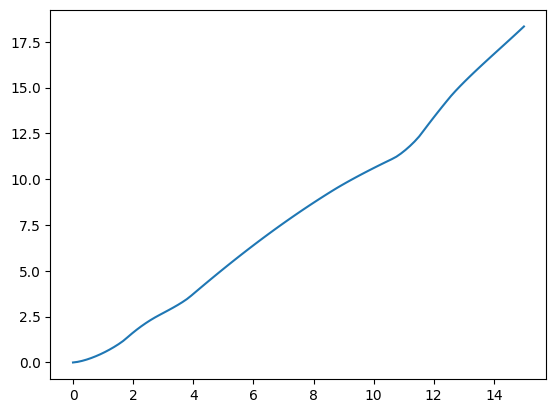

In [17]:
plt.plot(mu_kHz_range, all_ns)
n3D_per_um3_hc_mu_kHz_interp = interp1d(
    mu_kHz_range, 
    all_ns, 
    kind='linear', 
    bounds_error=False, 
    fill_value=(0, n_of_mu[-1])
)

# Local density approximation

In [18]:
fx_trap_Rb = 49.83    # Measured 2026/01/09
fy_trap_Rb = 70.65    # Measured 2026/01/09
fz_trap_Rb = 256.08   # Measured 2026/01/13
N_Rb = 1e5
N_K40 = 8e4

In [19]:
# Rb stuff
wx_trap_Rb = fx_trap_Rb * 2 * np.pi
wy_trap_Rb = fy_trap_Rb * 2 * np.pi
wz_trap_Rb = fz_trap_Rb * 2 * np.pi
Rx_TF_Rb = E9ct.fermi_radius_Rb(wx_trap_Rb, N_Rb)   # change! I don't like fermi_radius()
Ry_TF_Rb = E9ct.fermi_radius_Rb(wy_trap_Rb, N_Rb)   # change! I don't like fermi_radius()
Rz_TF_Rb = E9ct.fermi_radius_Rb(wz_trap_Rb, N_Rb)   # change! I don't like fermi_radius()

# K stuff
alpha_ratio = E9pol.alpha_s_K_4S1o2(1064e-9) / E9pol.alpha_s_Rb_5S1o2(1064e-9)
print(alpha_ratio)
fx_trap_K = fx_trap_Rb * np.sqrt(E9c.m_Rb87 / E9c.m_K40 * alpha_ratio)
fy_trap_K = fy_trap_Rb * np.sqrt(E9c.m_Rb87 / E9c.m_K40 * alpha_ratio)
fz_trap_K = fz_trap_Rb * np.sqrt(E9c.m_Rb87 / E9c.m_K40 * alpha_ratio)
wx_trap_K = fx_trap_K * 2 * np.pi
wy_trap_K = fy_trap_K * 2 * np.pi
wz_trap_K = fz_trap_K * 2 * np.pi

fbar_trap_K = (fx_trap_K * fy_trap_K * fz_trap_K)**(1/3)
wbar_trap_K = fbar_trap_K * 2 * np.pi
EF_trap_kHz_K = E9ct.fermi_energy_har(wbar_trap_K, N_K40) / E9c.hnobar / 1e3
Rx_TF_K = np.sqrt(2 * EF_trap_kHz_K * 1e3 * E9c.hnobar / (E9c.m_K40 * wx_trap_K**2)) # E9ct.fermi_radius_K40(wx_trap_K, N_K40)
Ry_TF_K = np.sqrt(2 * EF_trap_kHz_K * 1e3 * E9c.hnobar / (E9c.m_K40 * wy_trap_K**2)) # E9ct.fermi_radius_K40(wy_trap_K, N_K40)
Rz_TF_K = np.sqrt(2 * EF_trap_kHz_K * 1e3 * E9c.hnobar / (E9c.m_K40 * wz_trap_K**2)) # E9ct.fermi_radius_K40(wz_trap_K, N_K40)

print(f"(For K) f_x = {fx_trap_K:.3f}, f_y = {fy_trap_K:.3f}, f_z = {fz_trap_K:.3f}, fbar = {fbar_trap_K:.3f}")
print(f"Thomas-Fermi radii with {N_K40} K40 atoms without lattice (in um):")
print(f"    Rb: Rx = {Rx_TF_Rb * 1e6:.3f}, Ry = {Ry_TF_Rb * 1e6:.3f}, Rz = {Rz_TF_Rb * 1e6:.3f}")
print(f"   K40: Rx = {Rx_TF_K * 1e6:.3f}, Ry = {Ry_TF_K * 1e6:.3f}, Rz = {Rz_TF_K * 1e6:.3f}")
print(f"   Fermi energy = {EF_trap_kHz_K} kHz")

0.8745068703220287
(For K) f_x = 68.718, f_y = 97.430, f_z = 353.147, fbar = 133.221
Thomas-Fermi radii with 80000.0 K40 atoms without lattice (in um):
    Rb: Rx = 8.463, Ry = 7.360, Rz = 4.397
   K40: Rx = 33.427, Ry = 23.576, Rz = 6.504
   Fermi energy = 10.430855170955386 kHz


In [20]:
# triple integral and such
# scale factors to make things on the order of unity
scw = 1e3
scR = 1e6
scV = E9c.m_K40 * (scw / scR)**2 / E9c.hnobar / 1e3
wx_kHz, wy_kHz, wz_kHz = wx_trap_K / scw, wy_trap_K / scw, wz_trap_K / scw
mu_kHz = 10
Rx_um = np.sqrt(2 * mu_kHz * 1e3 * E9c.hnobar / (E9c.m_K40 * wx_trap_K**2)) * scR
print(Rx_um)

32.72904341648224


In [ ]:
trap_DOS_factor = (4 * np.pi * np.sqrt(2)) / (wx_kHz * wy_kHz * wz_kHz * scV**(3/2))

def dN_dU(U):
    # The local chemical potential is just global mu minus the local potential U
    local_mu = mu_kHz - U
    
    # Volume element scaled by the density
    return n3D_per_um3_hc_mu_kHz_interp(local_mu) * trap_DOS_factor * np.sqrt(U)

U_grid = np.linspace(0, mu_kHz, 10000)
integrand_vals = dN_dU(U_grid)
N_at_mu_kHz = np.trapz(integrand_vals, U_grid)

print(f"N = {N_at_mu_kHz}")

N = 80381.02397425022


C:\Users\ken92\AppData\Local\Temp\ipykernel_15300\1512118077.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  N_at_mu_kHz = np.trapz(integrand_vals, U_grid)


In [ ]:
nu_z_kHz = (wz_trap_K / (2 * np.pi)) / 1000
print(f"mu = {mu_kHz * 1e3:.3f} Hz")
print(f"f_z = {nu_z_kHz * 1e3:.3f} Hz")

# Define the 2D Spatial Area DOS factor
area_DOS_factor = (2 * np.pi) / ((E9c.m_K40 * wx_trap_K * wy_trap_K) * 1e-12 / E9c.hnobar / 1e3)

# Sum over the quantized z-levels
N_total = 0
n = 0

while True:
    En_kHz = nu_z_kHz * (n + 0.5)
    mu_n_kHz = mu_kHz - En_kHz  # energy left for honeycomb
    if mu_n_kHz <= 0:
        break
        
    # Do the integral in the energy axis by trapezoidal rule
    U_grid = np.linspace(0, mu_n_kHz, 5000)
    local_mu_kHz = mu_n_kHz - U_grid
    density_2D_um2 = n_per_uc_hc_mu_kHz(local_mu_kHz) * E9c.n_site_hex / 2 / 1e12
    integrand_vals = density_2D_um2 * area_DOS_factor   # n_2D(U_xy) * dArea/dU_xy
    N_total += np.trapz(integrand_vals, U_grid)
    
    n += 1

# Print the final result and the number of populated transverse bands
print(f"Total N = {N_total:.2f} atoms (Populated z-modes: {n})")

mu = 10000.000 Hz
f_z = 353.147 Hz
Total N = 80359.38 atoms (Populated z-modes: 28)


C:\Users\ken92\AppData\Local\Temp\ipykernel_15300\2816863129.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  N_total += np.trapz(integrand_vals, U_grid)
